# **Task-1:Environment setup and Data pipeline**

**Framework Used:TensorFlow/Keras**


Importing Libraries and setting random seeds to 42

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
# Setting all random seeds to 42
random.seed(42) # random.seed controls Python's random operations
np.random.seed(42) # np.random.seed controls NumPy based randomness
tf.random.set_seed(42) # tf.random.set_seed controls TensorFlow randomness

**Problem1:Environment verification**

In [2]:
print("NumPy version :", np.__version__)
print("Pandas version :", pd.__version__)
print("TensorFlow version :", tf.__version__)
print("Matplotlib version :", plt.matplotlib.__version__)

gpus=tf.config.list_physical_devices("GPU")
print("Available GPUs :", gpus)

NumPy version : 2.0.2
Pandas version : 2.2.2
TensorFlow version : 2.19.0
Matplotlib version : 3.10.0
Available GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


- we see no GPU available so training will run on CPU.
- CPU training is slower because matrix operations can not work as in parallel as they do on GPU.
- On a GPU machine it would be easier to train larger models faster.

**Problem2:Dataset exploration**

**Loading datasets**

In [3]:
(mnist_x_train,mnist_y_train),(mnist_x_test,mnist_y_test)=tf.keras.datasets.mnist.load_data()
(cifar_x_train,cifar_y_train),(cifar_x_test,cifar_y_test)=tf.keras.datasets.cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Inspecting shapes,dtype,value range

In [4]:
print("MNIST training image shape :", mnist_x_train.shape)
print("MNIST test image shape     :", mnist_x_test.shape)
print("MNIST training labels shape:", mnist_y_train.shape)
print("MNIST test labels shape    :", mnist_y_test.shape)
print()
print("CIFAR-10 training image shape :", cifar_x_train.shape)
print("CIFAR-10 test image shape     :", cifar_x_test.shape)
print("CIFAR-10 training labels shape:", cifar_y_train.shape)
print("CIFAR-10 test labels shape    :", cifar_y_test.shape)
print(" Data Types ")
print("MNIST image dtype   :", mnist_x_train.dtype)
print("MNIST label dtype   :", mnist_y_train.dtype)
print("CIFAR image dtype   :", cifar_x_train.dtype)
print("CIFAR label dtype   :", cifar_y_train.dtype)
print(" Pixel value ranges before Preprocessing ")
print("MNIST min value :", mnist_x_train.min(), " max value :", mnist_x_train.max())
print("CIFAR min value :", cifar_x_train.min(), " max value :", cifar_x_train.max())

MNIST training image shape : (60000, 28, 28)
MNIST test image shape     : (10000, 28, 28)
MNIST training labels shape: (60000,)
MNIST test labels shape    : (10000,)

CIFAR-10 training image shape : (50000, 32, 32, 3)
CIFAR-10 test image shape     : (10000, 32, 32, 3)
CIFAR-10 training labels shape: (50000, 1)
CIFAR-10 test labels shape    : (10000, 1)
 Data Types 
MNIST image dtype   : uint8
MNIST label dtype   : uint8
CIFAR image dtype   : uint8
CIFAR label dtype   : uint8
 Pixel value ranges before Preprocessing 
MNIST min value : 0  max value : 255
CIFAR min value : 0  max value : 255


MNIST class balance

In [5]:
mnist_class_counts = np.bincount(mnist_y_train)

print("MNIST training samples per class:\n")
for digit, count in enumerate(mnist_class_counts):
    print(f"Class {digit}: {count}")


MNIST training samples per class:

Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


It is balanced because all classes have similar number of samples

Plot

/tmp/ipykernel_1611/463744777.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[1][i].set_title(classes[int(label)])


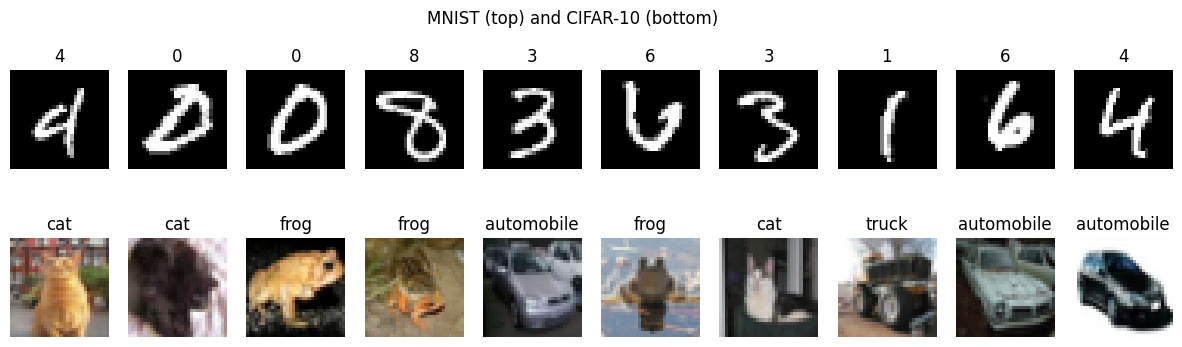

In [6]:
# class names for CIFAR-10
classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

# picking 10 random images
mnist_idx = np.random.randint(0, len(mnist_x_train), 10)
cifar_idx = np.random.randint(0, len(cifar_x_train), 10)

fig, ax = plt.subplots(2, 10, figsize=(15,4))

# MNIST images (top row)
for i in range(10):
    ax[0][i].imshow(mnist_x_train[mnist_idx[i]], cmap='gray')
    ax[0][i].set_title(str(mnist_y_train[mnist_idx[i]]))
    ax[0][i].axis("off")

# CIFAR images (bottom row)
for i in range(10):
    img = cifar_x_train[cifar_idx[i]]
    label = cifar_y_train[cifar_idx[i]]

    ax[1][i].imshow(img)
    ax[1][i].set_title(classes[int(label)])
    ax[1][i].axis("off")

plt.suptitle("MNIST (top) and CIFAR-10 (bottom)")
plt.savefig("dataset_samples.png")
plt.show()

**Problem3:Preprocessing pipeline**

Preprocessing function

In [7]:
# function to preprocess data
def preprocess_data(images, labels, name):
    print("dataset:", name)
    # before preprocessing
    print("before")
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    print("labels shape:", labels.shape)
    # normalizing
    images = images.astype("float32") / 255.0
    print("\nafter normalize")
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    # add channel if needed
    if len(images.shape) == 3:
        images = np.expand_dims(images, -1)
    print("\nafter reshape:", images.shape)
    # one hot encoding
    labels = tf.keras.utils.to_categorical(labels, 10)
    print("\nafter one hot:", labels.shape)
    return images, labels

preprocessing MNIST

In [8]:
# applying preprocessing on mnist train data
mnist_x_train_p, mnist_y_train_p = preprocess_data(mnist_x_train, mnist_y_train, "mnist train")

# applying preprocessing on mnist test data
mnist_x_test_p, mnist_y_test_p = preprocess_data(mnist_x_test, mnist_y_test, "mnist test")

dataset: mnist train
before
shape: (60000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (60000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (60000, 28, 28, 1)

after one hot: (60000, 10)
dataset: mnist test
before
shape: (10000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (10000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (10000, 28, 28, 1)

after one hot: (10000, 10)


**Problem4:Data Augmentation Pipeline**

Creating augmentaion layers

In [9]:
# creating augmentation layers
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # flip image left-right
    tf.keras.layers.RandomRotation(0.1),        # small rotation
    tf.keras.layers.RandomZoom(0.1)             # slight zoom
])

Augmentation results

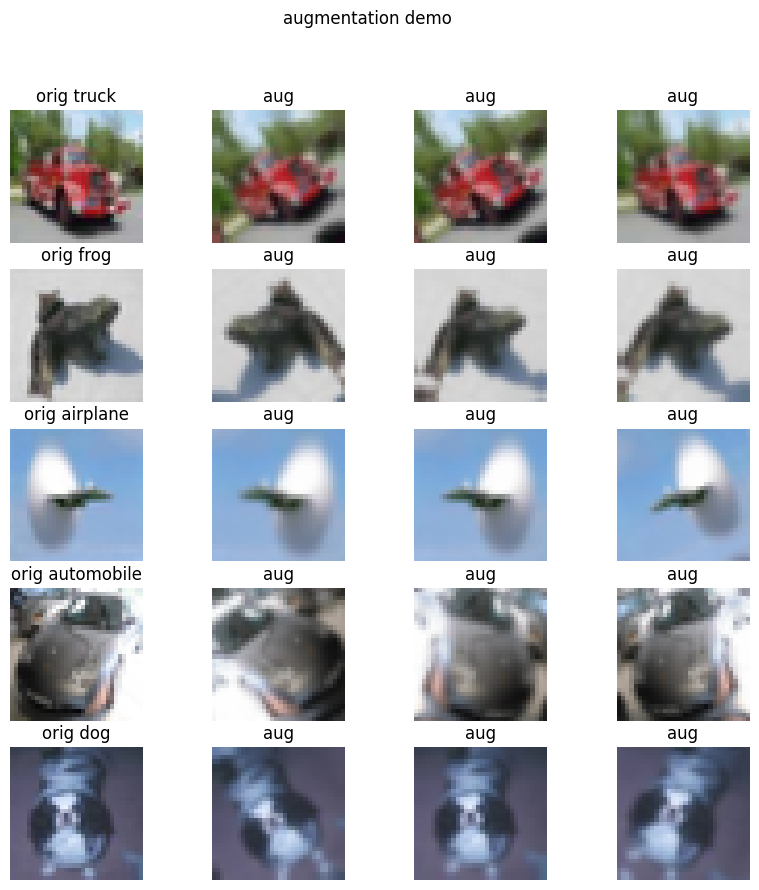

In [10]:
# taking 5 random images
idx = np.random.randint(0, len(cifar_x_train), 5)
fig, ax = plt.subplots(5, 4, figsize=(10,10))
for i in range(5):

    img = cifar_x_train[idx[i]]
    label = cifar_y_train[idx[i]][0]
    # original image
    ax[i][0].imshow(img)
    ax[i][0].set_title("orig " + classes[label])
    ax[i][0].axis("off")
    # augmented images
    for j in range(1,4):
        out = aug(tf.expand_dims(img, 0), training=True)
        out = tf.squeeze(out).numpy()
        out = np.clip(out, 0, 255).astype("uint8")
        ax[i][j].imshow(out)
        ax[i][j].set_title("aug")
        ax[i][j].axis("off")

plt.suptitle("augmentation demo")
plt.savefig("augmentation_demo.png")
plt.show()

**ANALYSIS & REFLECTION QUESTIONS**

Answer1:
- The channel dimension represents how many values each pixel has
- For grayscale images like MNIST, each pixel has only one value so the shape is (N, H, W, 1)
- For RGB images like CIFAR-10, each pixel has three values (red, green, blue) so the shape is (N, H, W, 3)

Answer2:
- If the image size is very large like 1024x1024, it can take a lot of memory. One way to handle this is by resizing the images to a smaller size before training.
- Another method is using smaller batch sizes so that fewer images are processed at once.
- We can also use cropping or patch-based training where we divide large images into smaller parts and train on those.
- These methods help in reducing memory usage and make training possible.

Answer3:
- This is wrong because it uses information from the test set, which should not be used during preprocessing.
- The test set is supposed to be completely unseen data. If we calculate mean and standard deviation from the test set, it leads to data leakage.
- The correct approach is to calculate these values using only the training data and then apply them to both validation and test sets.

###**Task2:Building a CNN from scratch**

**Manual 2D convolution**

conv2d function

In [11]:
# function for 2d convolution using only numpy
def conv2d(image, kernel, stride=1, padding=0):

    # add zero padding if needed
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode="constant")

    h, w = image.shape
    kh, kw = kernel.shape

    out_h = ((h - kh) // stride) + 1
    out_w = ((w - kw) // stride) + 1

    out = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(patch * kernel)

    return out

Testing image, kernel

In [13]:
img = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

out = conv2d(img, kernel, stride=1, padding=0)

print("Input image:\n", img)
print("Kernel:\n", kernel)
print("Output:\n", out)
print("Output shape:", out.shape)

Input image:
 [[3 1 0 2 4]
 [1 5 3 2 1]
 [0 2 6 4 3]
 [2 3 1 5 2]
 [1 0 2 3 4]]
Kernel:
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


Manual shape veriffication

In [14]:
n = 5
f = 3
p = 0
s = 1
out_size = ((n - f + 2*p) // s) + 1
print("Output size formula result:", out_size, "x", out_size)

Output size formula result: 3 x 3


**Problem2:Output Size Derivation**

Formula used:
Output size = floor((N - F + 2P) / S) + 1
a)Input = 28x28, Kernel = 5x5, Padding = 0, Stride = 1
Output = ((28 - 5 + 2x0) / 1) + 1

=24

Final output size =24 x 24

b)Input = 28x28, Kernel = 3x3, Padding = 1, Stride = 1
Output = ((28-3+2x1)/1)+1

=28

Final output size =28 x 28

c)Input = 32x32, Kernel = 3x3, Padding = 0, Stride = 2
Output = ((32-3+0)/2)+1
=floor(29/2)+1
=15

Final output size =15x15

d)First Conv layer: K = 3, P = 1, S = 1 on 32x32

Output = ((32 - 3 + 2x1) / 1) + 1  
= 32

So after first layer = 32x32

Second Conv layer: K = 3, P = 0, S = 1 on 32x32

Output = ((32 - 3 + 0) / 1) + 1  
= 30

Final output size = 30x30


**Problem3:Implement LeNet-5**

Building LeNet-5

In [17]:
# lenet 5 model
lenet = models.Sequential()

lenet.add(layers.Input(shape=(28, 28, 1)))

lenet.add(layers.Conv2D(6, (5,5), activation="tanh", padding="valid"))
lenet.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

lenet.add(layers.Conv2D(16, (5,5), activation="tanh", padding="valid"))
lenet.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

lenet.add(layers.Flatten())
lenet.add(layers.Dense(120, activation="tanh"))
lenet.add(layers.Dense(84, activation="tanh"))
lenet.add(layers.Dense(10, activation="softmax"))

Summary

In [18]:
lenet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Verifying parameter count

In [19]:
print("Total params:", lenet.count_params())

Total params: 44426


b)For the first Conv2D layer:

Formula:
(KxKxC_in + 1)xC_out

Here,
K = 5  
C_in = 1  
C_out = 6

So,
(5x5x1+1)x6  
= (25 + 1) × 6  
= 26x6  
= 156

So the first convolution layer has 156 parameters.

The total number of parameters in the LeNet-5 model is 44,426, which matches the model summary.

c)AvgPooling was used in LeNet-5 because at that time it was commonly used to reduce spatial size smoothly by averaging nearby values. Today, MaxPooling is used more often because it keeps the strongest activation, which usually helps the model capture important features better.

**Problem4:Design a Custom CNN for CIFAR-10**

#Sketch
Input (32x32x3)  
- Conv(32, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(64, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(128, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(256, 3x3) → BatchNorm → ReLU → MaxPool  
- GlobalAveragePooling  
- Dropout(0.4)  
- Dense(128, ReLU)  
- Dense(10, Softmax)

**Design rationale**

here we used four convolution blocks so that the model can learn simple features in early layers and more complex features in deeper layers. Batch Normalisation is added to make training more stable, and ReLU is used because it works well in deep CNNs. Pooling gradually reduces spatial size and computation, also used GlobalAveragePooling before the Dense layers to reduce the number of parameters, and Dropout is added to reduce overfitting

Building custom CNN

In [20]:
# custom cnn for cifar 10
cnn = models.Sequential()
cnn.add(layers.Input(shape=(32, 32, 3)))
cnn.add(layers.Conv2D(32, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(64, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(128, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(256, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.GlobalAveragePooling2D())
cnn.add(layers.Dropout(0.4))
cnn.add(layers.Dense(128, activation="relu"))
cnn.add(layers.Dense(10, activation="softmax"))

Summary

In [21]:
cnn.summary()
print("Total params:", cnn.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,522 (1.62 MB)

 Trainable params: 423,562 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

Total params: 424522


**Analysis & Reflection Questions**

Answer1:
Two stacked 3x3 convolution layers are more parameter efficient than one 5x5 convolution layer when the number of input and output channels is the same.

For example, if input channels = output channels = C, then:

One 5x5 conv layer needs:
25C² parameters

Two 3x3 conv layers need:
9C² + 9C² = 18C² parameters

So two 3x3 layers use fewer parameters than one 5x5 layer.

Another advantage is that stacking two 3x3 layers adds one extra non-linearity between them, which helps the network learn more complex patterns. It also gives nearly the same receptive field as a 5x5 convolution, but in a more efficient way

Answer2:
Batch Normalisation helps make training more stable by normalising the activations during training. It is usually placed after the convolution layer and before the activation function.

So the usual order is:
Conv → BatchNorm → ReLU

This helps because the values passed to the activation function stay in a better range.

Two practical benefits are:
1. Training becomes faster and more stable.
2. The model can often use a higher learning rate and becomes less sensitive to initialization.

It also acts as a small regulariser in many cases

Answer3:
GlobalAveragePooling takes each feature map and computes a single average value from it. So if there are many feature maps, it converts each one into one number.

Geometrically, it means the spatial information is compressed into one average response per channel.

If we replace it with Flatten, the parameter count will increase a lot because all spatial values will be sent to the Dense layer. Flatten keeps more detailed spatial information, but it also increases memory use and the chance of overfitting.

GlobalAveragePooling reduces parameters and makes the model lighter, but some fine spatial details are lost